# Predição de impedância de PDN com restrições físicas — pipeline completo

**TCC — Engenharia Elétrica, UFPR** · André Victor Xavier Pires (GRR20212735) · Orientador: Prof. Dr. Leandro dos Santos Coelho

Arquivo único com todo o processamento feito até a primeira avaliação de TCC I, sobre o subconjunto
**PI-4** da SI/PI-Database (*6-Layer PCB based PDN with two Via Arrays, Latin Hypercube Sampling*, 985 simulações).

| Seção | Conteúdo |
|---|---|
| 1 | configuração e leitura dos dados (cache reduzido ou Touchstone bruto) |
| 2 | verificação física R1 — comportamento capacitivo |
| 3 | integridade dos dados: correspondência entre CSV e arquivos |
| 4 | lei quase-estática sobre o bloco confiável |
| 5 | modelo de referência e métricas (R², RMSE, nRMSE) |
| 6 | análise de sensibilidade com SALib |
| 7 | inferência causal com DoWhy (opcional) |
| 8 | tempo de execução |

**Como usar no Colab.** Crie a pasta `MyDrive/TCC_PDN/` no Google Drive e coloque nela:
- **modo `cache`** (recomendado, ~1 min): o arquivo `pdn6_cache.npz` (1,2 MB), com as curvas |Z11(f)| já reduzidas;
- **modo `bruto`**: a pasta `6_layer_pcb_based_pdn_with_two_arrays_LHS_mar_2023/` (23 GB descompactados),
  com `parameter.csv` e `variation/`. No Colab a leitura pelo Drive é lenta — use `LIMITE` para testar com poucos arquivos.

Depois, *Ambiente de execução → Executar tudo*.

**Dados.** SI/PI-Database, Institut für Theoretische Elektrotechnik, TUHH. Uso sujeito aos termos da TUHH e à citação de
M. Schierholz *et al.*, "SI/PI-Database of PCB-Based Interconnects for Machine Learning Applications",
*IEEE Access*, v. 9, p. 34423–34432, 2021. A base original não é redistribuída.

**Declaração de uso de IA generativa** (Portaria CNPq nº 2.664/2026, art. 9º, I, c). Ferramenta: Claude (Anthropic), via
Claude Code. Finalidade: apoio à implementação de código a partir de especificações escritas pelo autor, e organização
deste notebook. Formulação do problema, hipóteses, desenho experimental e interpretação dos resultados são do autor, que
responde integralmente pelo conteúdo.

## 1. Configuração e leitura dos dados

In [1]:
MODO = "cache"          # "cache" (curvas já reduzidas) ou "bruto" (arquivos Touchstone)
LIMITE = None           # no modo bruto, ler só N arquivos espalhados (None = todos)
EXECUTAR_DOWHY = False  # seção 7: instala o dowhy (no Colab pode exigir reiniciar o ambiente)
SIMU_CONFIAVEL = 1500   # fronteira observada na seção 3

import sys, time, subprocess, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
T = {}                                   # tempos por etapa
t0 = time.perf_counter()

EM_COLAB = "google.colab" in sys.modules
if EM_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = Path("/content/drive/MyDrive/TCC_PDN")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "SALib"], check=True)
else:
    BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/processed").exists())

CACHE = BASE / "pdn6_cache.npz" if EM_COLAB else BASE / "data/processed/pdn6_cache.npz"
BRUTO = BASE / "6_layer_pcb_based_pdn_with_two_arrays_LHS_mar_2023"

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
print(f"Colab: {EM_COLAB} | modo: {MODO} | base: {BASE}")
T["configuração"] = time.perf_counter() - t0

Colab: False | modo: cache | base: /home/andre/Downloads/TCC


### Leitura de Touchstone e conversão S → Z

Cada arquivo `simu_<i>.s36p` guarda a matriz de espalhamento **S** (36×36, complexa) em 334 frequências de 1 MHz a 1 GHz.
A impedância vem de $Z = Z_0 (I + S)(I - S)^{-1}$, resolvida como sistema linear (sem inversa explícita).
O alvo do TCC é a autoimpedância $Z_{11}(f)$ na porta 0.

In [2]:
MIL = 25.4e-6
EPS0 = 8.8541878128e-12
FEATURES = ["TDIEL", "PERMITTIVITY", "A1_VIARADIUS", "A1_ANTIPADRADIUS",
            "A1_VIAPITCH", "A2_VIARADIUS", "A2_ANTIPADRADIUS", "A2_VIAPITCH"]

def ler_touchstone(caminho, n_portas):
    # O formato quebra os 2P² valores de cada frequência em várias linhas:
    # concatena tudo e reagrupa por contagem.
    linhas = [l.strip() for l in open(caminho) if l.strip() and l.strip()[0] not in "!#"]
    v = np.array(" ".join(linhas).split(), dtype=float)
    passo = 1 + 2 * n_portas ** 2
    assert v.size % passo == 0, f"{caminho}: contagem inválida"
    b = v.reshape(-1, passo)
    par = b[:, 1:].reshape(-1, n_portas, n_portas, 2)
    return b[:, 0], par[..., 0] + 1j * par[..., 1]

def s_para_z(s, z0=50.0):
    I = np.eye(s.shape[1])
    return z0 * np.swapaxes(np.linalg.solve(np.swapaxes(I - s, 1, 2), np.swapaxes(I + s, 1, 2)), 1, 2)

def z11_do_arquivo(caminho, n_portas=36, porta=0):
    freq, s = ler_touchstone(caminho, n_portas)
    return freq, np.abs(s_para_z(s)[:, porta, porta])

def c_placas(eps_r, a, b, h):
    return EPS0 * eps_r * a * b / h

In [3]:
t0 = time.perf_counter()
if MODO == "cache":
    d = np.load(CACHE)
    X, Y, freq, simu = d["X"].astype(float), d["y"].astype(float), d["freq"], d["simu_index"]
else:
    from concurrent.futures import ProcessPoolExecutor
    df = pd.read_csv(BRUTO / "parameter.csv")
    if LIMITE:  # amostra espalhada por todo o intervalo de simu_index
        df = df.iloc[np.linspace(0, len(df) - 1, LIMITE).astype(int)]
    caminhos = [BRUTO / "variation" / f"simu_{int(i)}.s36p" for i in df["simu_index"]]
    with ProcessPoolExecutor() as ex:
        res = list(ex.map(z11_do_arquivo, caminhos, chunksize=4))
    freq = res[0][0]
    Y = np.array([r[1] for r in res])
    X = df[FEATURES].to_numpy(float)
    simu = df["simu_index"].to_numpy()
T["leitura dos dados"] = time.perf_counter() - t0
print(f"X {X.shape} · Y {Y.shape} · {freq[0]/1e6:.0f} MHz a {freq[-1]/1e9:.0f} GHz, {len(freq)} pontos")
print(f"leitura: {T['leitura dos dados']:.1f} s")

X (985, 8) · Y (985, 334) · 1 MHz a 1 GHz, 334 pontos
leitura: 0.0 s


## 2. Verificação física R1 — comportamento capacitivo

Abaixo do nulo de série a PDN é um capacitor: $|Z_{11}| \propto 1/f$, logo a inclinação log–log vale −1.
Medida nos 8 primeiros pontos (1 a 22 MHz).

In [4]:
t0 = time.perf_counter()
incl = np.polyfit(np.log10(freq[:8]), np.log10(Y[:, :8]).T, 1)[0]
T["R1"] = time.perf_counter() - t0
print(f"inclinação: {incl.mean():+.4f} ± {incl.std():.4f}")
print(f"dentro de [-1,05; -0,95]: {np.mean((incl > -1.05) & (incl < -0.95)) * 100:.1f} % das configurações")

inclinação: -1.0197 ± 0.0062
dentro de [-1,05; -0,95]: 100.0 % das configurações


## 3. Integridade: os parâmetros do CSV descrevem as curvas dos arquivos?

A capacitância extraída de cada curva é comparada à de placas paralelas calculada com os parâmetros do CSV.
Se o arquivo corresponde à sua linha, a razão é estável (≈ 2,1: a porta enxerga duas cavidades em paralelo).

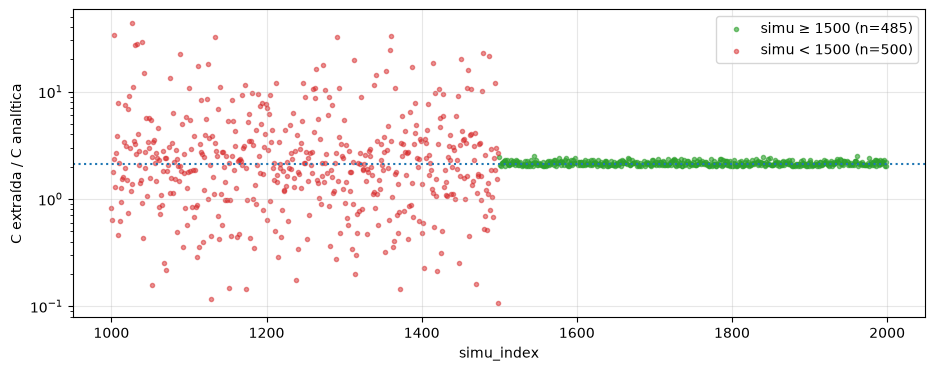

simu <  1500: n= 500  razão p5 0.35 | mediana 2.13 | p95 12.08
simu >= 1500: n= 485  razão p5 2.04 | mediana 2.13 | p95 2.33


In [5]:
t0 = time.perf_counter()
C_ext = np.median(1 / (2 * np.pi * freq[:8] * Y[:, :8]), axis=1)
C_ana = c_placas(X[:, 1], 5800 * MIL, 4000 * MIL, X[:, 0] * MIL)
razao = C_ext / C_ana
ok = simu >= SIMU_CONFIAVEL
T["integridade"] = time.perf_counter() - t0

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(simu[ok], razao[ok], s=9, c="tab:green", alpha=.6, label=f"simu ≥ {SIMU_CONFIAVEL} (n={ok.sum()})")
ax.scatter(simu[~ok], razao[~ok], s=9, c="tab:red", alpha=.5, label=f"simu < {SIMU_CONFIAVEL} (n={(~ok).sum()})")
ax.axhline(2.13, ls=":", c="tab:blue"); ax.set_yscale("log"); ax.legend(); ax.grid(alpha=.3)
ax.set_xlabel("simu_index"); ax.set_ylabel("C extraída / C analítica")
plt.show()
for nome, m in [("simu <  1500", ~ok), ("simu >= 1500", ok)]:
    if m.any():
        q = np.percentile(razao[m], [5, 50, 95])
        print(f"{nome}: n={m.sum():4d}  razão p5 {q[0]:.2f} | mediana {q[1]:.2f} | p95 {q[2]:.2f}")

## 4. Lei quase-estática sobre o bloco confiável

$\log|Z| = \log h - \log \varepsilon_r - \log(2\pi f \varepsilon_0 a b)$ prevê expoentes **+1** para a espessura e **−1** para a permissividade.

In [6]:
def lei(mask):
    A = np.column_stack([np.ones(mask.sum()), np.log10(X[mask, 0]), np.log10(X[mask, 1])])
    y = np.log10(Y[mask, 0]); b, *_ = np.linalg.lstsq(A, y, rcond=None); r = y - A @ b
    se = np.sqrt(np.diag(r @ r / (len(y) - 3) * np.linalg.inv(A.T @ A)))
    return b, 1.96 * se, 1 - r @ r / ((y - y.mean()) ** 2).sum()

for nome, m in [("todas", np.ones(len(X), bool)), ("bloco confiável", ok)]:
    if m.sum() > 10:
        b, ic, r2 = lei(m)
        print(f"{nome:16s} log h {b[1]:+.3f} ± {ic[1]:.3f} | log εr {b[2]:+.3f} ± {ic[2]:.3f} | R² {r2:.3f}")

todas            log h +0.428 ± 0.056 | log εr -0.574 ± 0.237 | R² 0.197
bloco confiável  log h +0.955 ± 0.004 | log εr -1.022 ± 0.016 | R² 0.998


## 5. Modelo de referência e métricas

Gradient boosting por ponto de frequência, validação cruzada em 5 dobras. Métricas conforme Hillebrecht *et al.* (2024):
R², RMSE (em décadas de $\log_{10}|Z|$) e nRMSE = RMSE / |média|.

In [7]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate
t0 = time.perf_counter()
cv = KFold(5, shuffle=True, random_state=42); linhas = []
for fm in (1, 10, 50, 97, 300, 600, 1000):
    k = int(np.argmin(np.abs(freq / 1e6 - fm))); lin = [f"{fm} MHz"]
    for m in (np.ones(len(X), bool), ok):
        if m.sum() < 50: lin += ["—"]; continue
        y = np.log10(Y[m, k])
        r = cross_validate(GradientBoostingRegressor(max_depth=2, n_estimators=400, learning_rate=.05, random_state=42),
                           X[m], y, cv=cv, scoring=("r2", "neg_root_mean_squared_error"))
        rmse = -r["test_neg_root_mean_squared_error"].mean()
        lin += [f"R² {r['test_r2'].mean():.3f} · RMSE {rmse:.4f} · nRMSE {rmse/abs(y.mean())*100:.1f}%"]
    linhas.append(lin)
T["modelo de referência"] = time.perf_counter() - t0
pd.DataFrame(linhas, columns=["log10|Z11| em", "todas as configurações", "bloco confiável"])

,log10|Z11| em,todas as configurações,bloco confiável
0,1 MHz,R² 0.111 · RMSE 0.2885 · nRMSE 13.3%,R² 0.995 · RMSE 0.0192 · nRMSE 0.9%
1,10 MHz,R² 0.109 · RMSE 0.2847 · nRMSE 24.7%,R² 0.996 · RMSE 0.0186 · nRMSE 1.6%
2,50 MHz,R² 0.113 · RMSE 0.2971 · nRMSE 90.0%,R² 0.994 · RMSE 0.0223 · nRMSE 6.0%
3,97 MHz,R² 0.027 · RMSE 0.4784 · nRMSE 86.1%,R² 0.721 · RMSE 0.2476 · nRMSE 41.2%
4,300 MHz,R² 0.034 · RMSE 0.3077 · nRMSE 50.4%,R² 0.993 · RMSE 0.0234 · nRMSE 4.4%
5,600 MHz,R² 0.045 · RMSE 0.3069 · nRMSE 31.9%,R² 0.994 · RMSE 0.0220 · nRMSE 2.5%
6,1000 MHz,R² 0.053 · RMSE 0.3439 · nRMSE 28.2%,R² 0.679 · RMSE 0.1913 · nRMSE 16.7%


## 6. Sensibilidade com SALib

Os dados já existem e foram amostrados por hipercubo latino. Por isso usam-se os métodos do SALib que aceitam **amostra dada**:
**RBD-FAST** (índice de primeira ordem S1), **delta** (δ, independente de momentos) e **PAWN**.
Sobol exige amostragem de Saltelli — será feito sobre o modelo substituto, numa etapa posterior.

Soma de S1 perto de 1 indica saída explicada por efeitos individuais, sem interações relevantes.

In [8]:
from SALib.analyze import rbd_fast, delta, pawn
import contextlib, io
t0 = time.perf_counter()
assert ok.sum() >= 60, f"só {ok.sum()} configurações confiáveis: aumente LIMITE"
Xo, Yo = X[ok], Y[ok]
prob = {"num_vars": 8, "names": FEATURES, "bounds": [[Xo[:, j].min(), Xo[:, j].max()] for j in range(8)]}
inull = Yo.argmin(1)
saidas = {"log|Z| em 1 MHz": np.log10(Yo[:, 0]), "f do nulo (MHz)": freq[inull] / 1e6,
          "log|Z| em 1 GHz": np.log10(Yo[:, -1])}
tabs = {}
for nome, y in saidas.items():
    r = rbd_fast.analyze(prob, Xo, y, seed=42)
    with contextlib.redirect_stdout(io.StringIO()):  # silencia avisos de agrupamento
        dl = delta.analyze(prob, Xo, y, seed=42, num_resamples=50)
    pw = pawn.analyze(prob, Xo, y, S=10, seed=42)
    tabs[nome] = pd.DataFrame({"S1 RBD-FAST": r["S1"], "± IC": r["S1_conf"],
                               "δ": dl["delta_balanced"], "PAWN mediana": pw["median"]},
                              index=FEATURES).sort_values("S1 RBD-FAST", ascending=False).round(3)
    print(f"{nome}: soma S1 = {np.sum(r['S1']):.3f}")
T["SALib"] = time.perf_counter() - t0
from IPython.display import display
for nome, t in tabs.items():
    print(f"\n=== {nome}"); display(t)

[A1_VIAPITCH][balanced] Bin Merge Notice: Final no. bins is 9. Min samples per bin: 10


[A2_VIAPITCH][balanced] Bin Merge Notice: Final no. bins is 9. Min samples per bin: 10


log|Z| em 1 MHz: soma S1 = 0.973


[A1_VIAPITCH][balanced] Bin Merge Notice: Final no. bins is 9. Min samples per bin: 10


[A2_VIAPITCH][balanced] Bin Merge Notice: Final no. bins is 9. Min samples per bin: 10


...

,S1 RBD-FAST,± IC,δ,PAWN mediana
TDIEL,0.924,0.019,0.563,0.548
PERMITTIVITY,0.070,0.076,0.115,0.176
A2_ANTIPADRADIUS,0.017,0.066,0.053,0.119
A1_VIAPITCH,0.001,0.056,0.052,0.104
A2_VIAPITCH,-0.000,0.061,0.060,0.098
A2_VIARADIUS,-0.008,0.076,0.066,0.160
A1_VIARADIUS,-0.009,0.066,0.055,0.118
A1_ANTIPADRADIUS,-0.022,0.064,0.057,0.095



=== f do nulo (MHz)


,S1 RBD-FAST,± IC,δ,PAWN mediana
PERMITTIVITY,0.540,0.083,0.266,0.304
A1_VIARADIUS,0.332,0.095,0.195,0.226
A1_VIAPITCH,0.075,0.086,0.140,0.132
TDIEL,0.020,0.066,0.083,0.108
A2_ANTIPADRADIUS,0.007,0.071,0.135,0.115
A2_VIAPITCH,0.004,0.059,0.059,0.079
A1_ANTIPADRADIUS,0.002,0.066,0.132,0.085
A2_VIARADIUS,-0.020,0.061,0.086,0.106



=== log|Z| em 1 GHz


,S1 RBD-FAST,± IC,δ,PAWN mediana
TDIEL,0.611,0.092,0.332,0.382
PERMITTIVITY,0.031,0.071,0.133,0.129
A1_VIAPITCH,0.024,0.065,0.090,0.100
A2_VIAPITCH,0.013,0.060,0.027,0.114
A1_VIARADIUS,0.010,0.080,0.083,0.106
A2_VIARADIUS,0.008,0.074,0.095,0.123
A2_ANTIPADRADIUS,-0.001,0.054,0.070,0.117
A1_ANTIPADRADIUS,-0.010,0.070,0.065,0.107


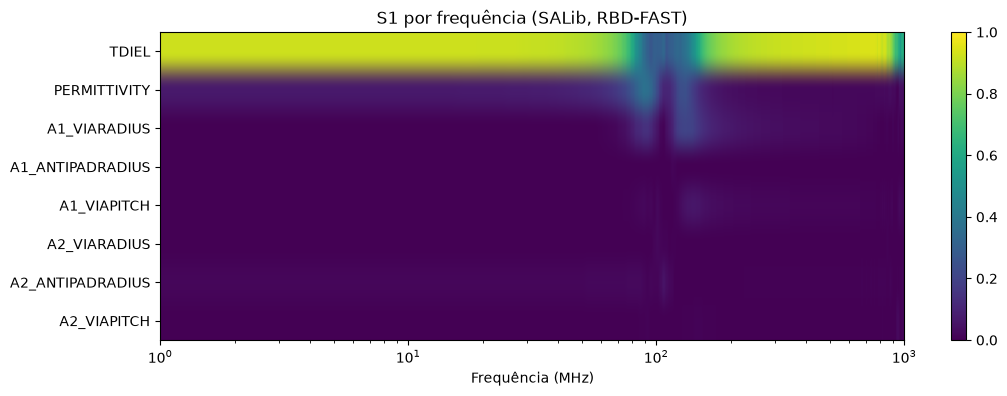

In [9]:
S1 = np.array([rbd_fast.analyze(prob, Xo, np.log10(Yo[:, k]), seed=42)["S1"] for k in range(len(freq))]).T
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(np.clip(S1, 0, 1), aspect="auto", cmap="viridis", vmin=0, vmax=1,
               extent=[freq[0]/1e6, freq[-1]/1e6, 7.5, -0.5])
ax.set_xscale("log"); ax.set_yticks(range(8)); ax.set_yticklabels(FEATURES)
ax.set_xlabel("Frequência (MHz)"); ax.set_title("S1 por frequência (SALib, RBD-FAST)")
plt.colorbar(im, ax=ax); plt.show()

## 7. Inferência causal com DoWhy (opcional)

Num experimento **projetado** (hipercubo latino), as entradas são atribuídas pelo experimentador: não há confundimento, e a
análise de sensibilidade já é a análise causal. O ganho do DoWhy está nos **testes de refutação**.
A célula compara o bloco confiável com os dados completos.

In [10]:
if EXECUTAR_DOWHY:
    if EM_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "dowhy"], check=True)
    import logging; logging.disable(logging.WARNING)
    from dowhy import CausalModel
    def efeito(mask, rotulo):
        df = pd.DataFrame(X[mask], columns=FEATURES)
        df["log_h"] = np.log10(df.TDIEL); df["log_er"] = np.log10(df.PERMITTIVITY)
        df["log_Z"] = np.log10(Y[mask, 0])
        m = CausalModel(data=df, treatment="log_h", outcome="log_Z", common_causes=["log_er"] + FEATURES[2:])
        ide = m.identify_effect(proceed_when_unidentifiable=True)
        est = m.estimate_effect(ide, method_name="backdoor.linear_regression")
        ref = m.refute_estimate(ide, est, method_name="placebo_treatment_refuter",
                                placebo_type="permute", num_simulations=30, random_seed=42)
        print(f"{rotulo:16s} efeito de log h: {est.value:+.3f} (física: +1) | placebo: {ref.new_effect:+.3f}")
    efeito(ok, "bloco confiável")
    efeito(np.ones(len(X), bool), "todas")
    print("\nOs dois passam no placebo: a refutação não detecta dados que não correspondem aos parâmetros.")
else:
    print("Seção desativada (EXECUTAR_DOWHY = False).")

Seção desativada (EXECUTAR_DOWHY = False).


## 8. Tempo de execução

In [11]:
tempos = pd.Series(T, name="segundos").round(1)
print(tempos.to_string()); print(f"\ntotal: {tempos.sum():.1f} s")

configuração             0.6
leitura dos dados        0.0
R1                       0.0
integridade              0.0
modelo de referência    17.5
SALib                   39.4

total: 57.5 s
